In [ ]:
!pip install yfinance
import yfinance as yf

STOCK = "MA"

data = yf.download(STOCK, start="2023-01-01", end="2026-02-06")

data.to_csv(f"{STOCK}.csv")

print(data.head())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

df = pd.read_csv(f"{STOCK}.csv")

prices = df["Close"].values.reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0, 1))
prices_scaled = scaler.fit_transform(data)

/tmp/ipython-input-3369111722.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(STOCK, start="2023-01-01", end="2026-02-06")
[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open   Volume
Ticker              MA          MA          MA          MA       MA
Date                                                               
2023-01-03  340.245483  347.956945  337.439552  343.345763  2933600
2023-01-04  348.437714  350.233144  343.080915  344.748797  2661000
2023-01-05  345.121613  350.802191  344.631062  349.389404  2608500
2023-01-06  361.306488  362.338303  349.170232  351.125780  4432800
2023-01-09  364.549438  368.509688  363.163838  365.198019  3913500


We scale data before training an LSTM to ensure stable feature learning. Without normalization, large input values cause poor model performance.

In [ ]:
def create_sequences(data, window_size):
  X= []
  y= []
  for i in range(window_size, len(data)):
    X.append(data[i-window_size:i, 0])
    y.append(data[i, 0])

  return np.array(X), np.array(y)

WINDOW_SIZE = 30

X, y = create_sequences(prices_scaled, WINDOW_SIZE)

X = X.reshape((X.shape[0], X.shape[1], 1))

train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

The sliding window approach converts a time series into overlapping sequences so the LSTM can learn patterns over time. Each window uses a fixed number of past values to predict a future value. The data is reshaped into a 3D format because LSTMs need sequence information to understand the order of data and the values at each time step.

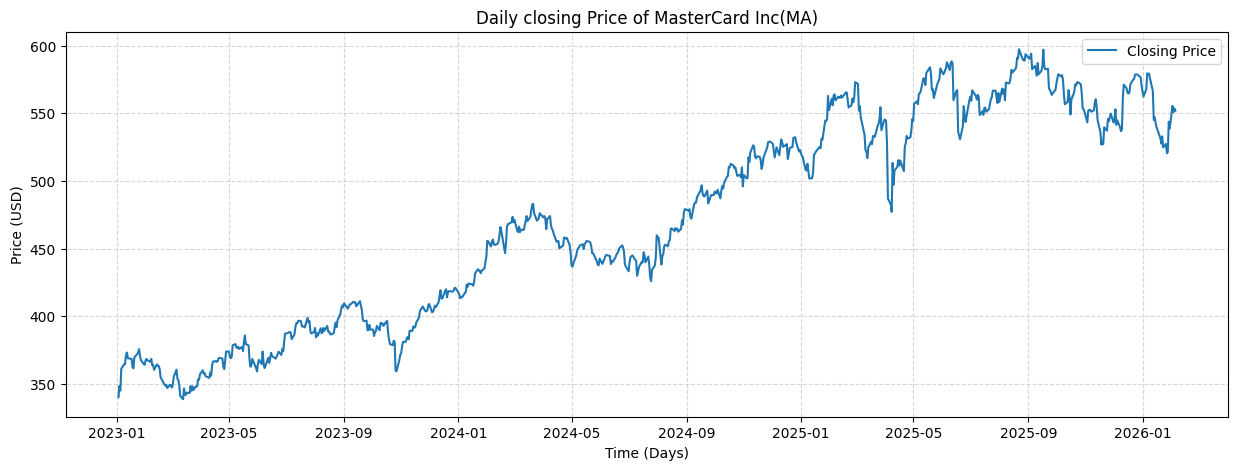

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(data['Close'], label='Closing Price')
plt.title('Daily closing Price of MasterCard Inc(MA)')
plt.xlabel('Time (Days)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The stock is generally increasing, with some volatility rather than a steady smooth rise.

In [ ]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], 1)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

Overall, the chosen LSTM architecture achieves a balance between learning complex patterns and avoiding overfitting. The stacked LSTM layers allow the model to capture both short-term price fluctuations and longer-term trends in MasterCards stock data, while the dropout layers reduce the impact of noise and improve generalization. This makes the model well-suited for predicting future stock prices using historical time-series data.

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 102ms/step - loss: 0.0968 - val_loss: 0.0495
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0115 - val_loss: 0.0053
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0060 - val_loss: 0.0054
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0050 - val_loss: 0.0054
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0046 - val_loss: 0.0052
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0056 - val_loss: 0.0052
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0049 - val_loss: 0.0050
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0045 - val_loss: 0.0056
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0039 - val_loss: 0.0071
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0042 - val_loss: 0.0068
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0038 - val_loss: 0.0049
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.

The training and validation loss decrease quickly at first and then level off, showing that the model learns effectively. The small difference between the two losses indicates little overfitting, while small changes in validation loss are expected due to normal stock price volatility.

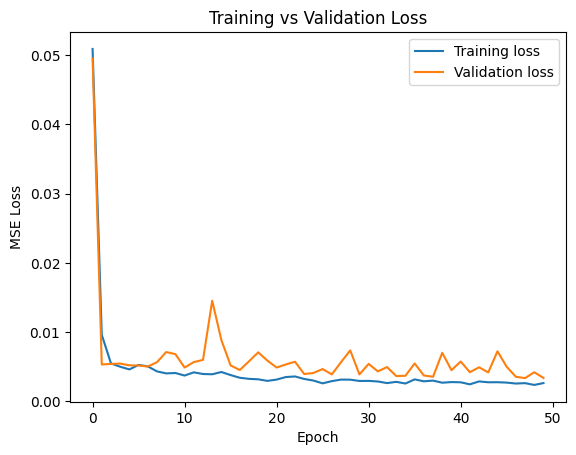

In [ ]:
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [ ]:
predictions = model.predict(X_test)

feature_scaler = MinMaxScaler(feature_range=(0, 1))
feature_scaler.fit(data['Close'].values.reshape(-1, 1))

predictions = feature_scaler.inverse_transform(predictions)
actual = feature_scaler.inverse_transform(y_test.reshape(-1, 1))

print(predictions)
print(" ")
print(actual)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step
[[590.01324]
 [591.48706]
 [592.33154]
 [592.6749 ]
 [593.0783 ]
 [593.113  ]
 [593.0739 ]
 [593.17554]
 [592.3236 ]
 [591.27655]
 [589.91486]
 [588.0928 ]
 [587.001  ]
 [585.62067]
 [584.52625]
 [583.96857]
 [584.86127]
 [585.38916]
 [585.6555 ]
 [585.7476 ]
 [584.43494]
 [582.3799 ]
 [579.8588 ]
 [577.058  ]
 [574.5982 ]
 [572.5897 ]
 [571.4858 ]
 [571.33606]
 [572.09076]
 [573.21533]
 [574.62134]
 [575.7818 ]
 [575.7413 ]
 [574.4071 ]
 [572.5333 ]
 [571.1776 ]
 [569.72784]
 [567.2871 ]
 [565.5108 ]
 [564.6375 ]
 [564.895  ]
 [565.7892 ]
 [567.25934]
 [568.9747 ]
 [570.59064]
 [571.4517 ]
 [570.80225]
 [569.256  ]
 [567.07   ]
 [563.95966]
 [561.3376 ]
 [559.1892 ]
 [557.544  ]
 [556.27234]
 [555.45953]
 [555.482  ]
 [556.25854]
 [556.9715 ]
 [556.79785]
 [555.375  ]
 [552.50464]
 [549.2155 ]
 [545.6565 ]
 [543.29297]
 [541.5818 ]
 [541.23016]
 [541.6355 ]
 [543.0408 ]
 [544.37714]
 [545.796  ]
 [547.794  ]
 [548.96106]
 [549.86304]
 [550.0259 ]

Overall, the model tracks the general movement of MasterCard’s stock prices well, producing smooth predictions that closely follow the real data, while struggling slightly with sudden market fluctuations.

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


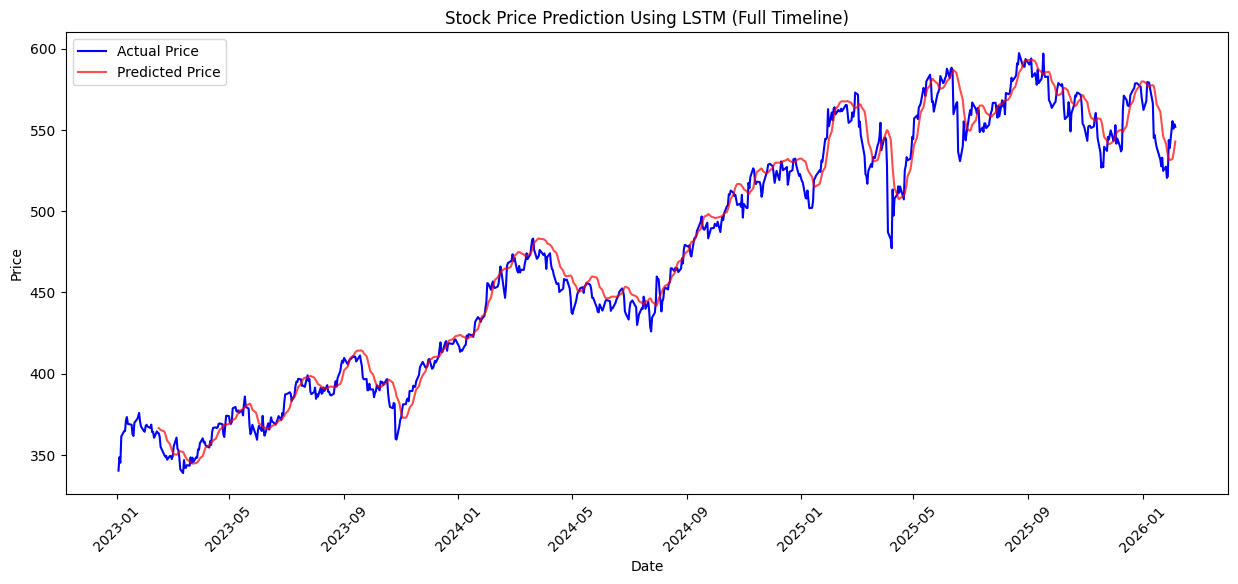

In [ ]:
close_scaler = MinMaxScaler()
close_scaler.fit(data['Close'].values.reshape(-1, 1))

train_pred = model.predict(X_train)
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

train_pred = close_scaler.inverse_transform(train_pred)
val_pred = close_scaler.inverse_transform(val_pred)
test_pred = close_scaler.inverse_transform(test_pred)

all_pred = np.empty_like(data['Close'].values).reshape(-1, 1)
all_pred[:] = np.nan

time_steps = X_train.shape[1]

all_pred[time_steps:len(train_pred) +time_steps] = train_pred
all_pred[len(train_pred) + time_steps:len(train_pred) + len(val_pred) + time_steps] = val_pred
all_pred[-len(test_pred):] = test_pred

plt.figure(figsize=(15,6))
plt.plot(data.index, data['Close'], label='Actual Price', color='blue')
plt.plot(data.index, all_pred, label='Predicted Price', color='red', alpha=0.7)
plt.title('Stock Price Prediction Using LSTM (Full Timeline)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

Across the full historical timeline, the model demonstrates strong overall fit by closely tracking long-term trends and price movements. However, it performs less accurately during periods of sudden volatility, where predictions appear smoother and slightly delayed compared to actual stock prices.

In [ ]:
WINDOW_SIZE = 30
future_days = 10

prices = data['Close'].values.reshape(-1,1)
close_scaler = MinMaxScaler()
prices_scaled = close_scaler.fit_transform(prices)

last_sequence = prices_scaled[-WINDOW_SIZE:].reshape(-1,1)
future_predictions = []
current_sequence = last_sequence.copy()

for _ in range(future_days):
  input_seq = current_sequence.reshape((1, WINDOW_SIZE, 1))
  next_price_scaled = model.predict(input_seq, verbose=0)[0, 0]
  future_predictions.append(next_price_scaled)
  current_sequence = np.append(current_sequence[1:], [[next_price_scaled]], axis=0)

future_predictions = close_scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

last_date = data.index[-1]
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=future_days,
    freq='B'
)

last_month_start = data.index[-30]
historical_last_month = data.loc[last_month_start:]

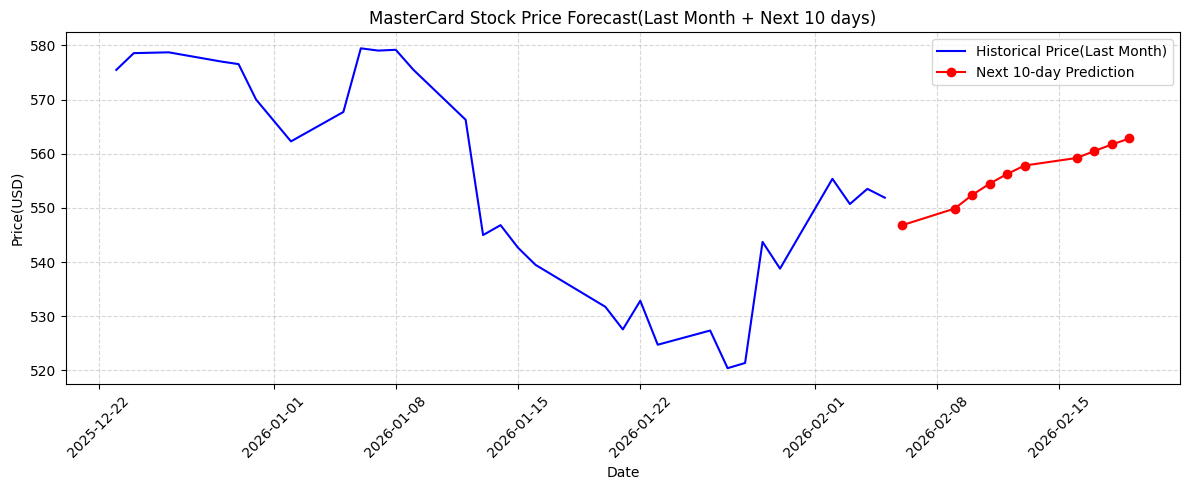

Next 10-day Prediction Prices: 
2026-02-06 : $546.81
2026-02-09 : $549.88
2026-02-10 : $552.39
2026-02-11 : $554.48
2026-02-12 : $556.26
2026-02-13 : $557.82
2026-02-16 : $559.23
2026-02-17 : $560.52
2026-02-18 : $561.71
2026-02-19 : $562.82


In [ ]:
plt.figure(figsize=(12,5))
plt.plot(historical_last_month.index, historical_last_month['Close'], label='Historical Price(Last Month)', color='blue')
plt.plot(future_dates, future_predictions, label='Next 10-day Prediction', color='red', marker='o')
plt.title("MasterCard Stock Price Forecast(Last Month + Next 10 days)")
plt.xlabel("Date")
plt.ylabel("Price(USD)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Next 10-day Prediction Prices: ")
for date, price in zip(future_dates, future_predictions):
  print(f"{date.date()} : ${price[0]:.2f}")

The 10-day forecast shows a steady upward trend, which is reasonable given the data observed in the historical data. However, the predictions are smoother than actual market behavior, reflecting the model’s tendency to extend recent trends rather than anticipate sudden volatility.